# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студенты гр. 2381 Ивашинников Леонид Дмитриевич и Двиков Даниил Владиславович. Вариант №23.

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.

## Основные теоретические положения
Ранжированный ряд – последовательность элементов выборки, расположенных в порядке возрастания их значений.

Вариационный ряд – совокупность уникальных значений признака с указанием их частоты встречаемости.

Интервальный ряд – вариационный ряд, разделённый на интервалы.

Гистограмма – столбчатая диаграмма, визуально отображающая распределение количественных данных, где высота каждого столбика (прямоугольника) пропорциональна частоте появления значений в определенном диапазоне.

Полигон – ломаная линия, соединяющая точки, соответствующие серединам интервалов и их частотам.

Эмпирическая функция распределения — ступенчатая функция, которая показывает накопленную относительную частоту до каждого значения признака.

## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

1. Выбрать программное обеспечение или язык программирования для выполнения практических работ и обосновать его выбор.

В качестве языка программирования был выбран Python. Он универсален, имеет обширный набор готовых библиотек и часто используется в аналогичных задачах.

2. Выбрать двумерную генеральную совокупность, предварительно согласовав её с преподавателем. Указать, откуда была взята генеральная совокупность и предоставить ссылку.

Были взяты данные наблюдения относительно объёмного веса $\nu$ ($кг/см^3$) при влажности 10% и модуля упругости $E$ ($кг/см^2$) при сжатии вдоль волокон древесины резонансной ели: [ссылка](https://se.moevm.info/lib/exe/fetch.php/courses:statistical_methods_of_experimental_data_handling:sample.zip).

3. Из генеральной совокупности сформировать выборку заданного объёма в соответствии с полученным от преподавателя номером. Указать, каким образом была сформирована выборка.

Выборка объёмом 109 пар сформирована путём случайного отбора.

4. Последовательно преобразовать выборку в ранжированный, вариационный и интервальный ряды. Интервальный ряд представить в виде таблицы. Результаты содержательно проинтерпретировать.

In [83]:
import pandas as pd


NU, E = 'nu (kg/cm^3)', 'E (kg/cm^2)'

df = pd.read_csv('/content/dataset.csv', sep=';')
df.describe()

,nu (kg/cm^3),E (kg/cm^2)
count,109.000000,109.000000
mean,0.449569,127.912844
std,0.054279,22.346406
min,0.320000,71.100000
25%,0.412000,114.800000
50%,0.448000,127.700000
75%,0.487000,143.800000
max,0.593000,187.400000


In [84]:
import numpy as np


INTERVAL = r'$[x_i,x_{i+1})$'
MIDRANGE = r'$\tilde x_i$'
FREQUENCY = r'$m_i$'
RELATIVE_FREQUENCY = r'$\tilde m_i$'
FREQUENCY_CUM_SUM = r'$m_i^{нак}$'
RELATIVE_FREQUENCY_CUM_SUM = r'$\tilde m_i^{нак}$'
SUM = r'$\sum$'


def sturges_interval_series(s: pd.Series) -> pd.DataFrame:
  n = len(s)
  k = int(1 + 3.322 * np.log10(n))

  intervals = pd.cut(s, bins=k, right=False)

  table = intervals.value_counts().sort_index().reset_index()

  table.columns = [INTERVAL, FREQUENCY]
  table[MIDRANGE] = table[INTERVAL].apply(lambda x: (x.left + x.right) / 2)
  table[RELATIVE_FREQUENCY] = table[FREQUENCY] / n
  table[FREQUENCY_CUM_SUM] = table[FREQUENCY].cumsum()
  table[RELATIVE_FREQUENCY_CUM_SUM] = table[RELATIVE_FREQUENCY].cumsum()

  table.index = range(1, len(table) + 1)

  sum_row = pd.DataFrame({
      INTERVAL: [''],
      MIDRANGE: [''],
      FREQUENCY: [table[FREQUENCY].sum()],
      RELATIVE_FREQUENCY: [table[RELATIVE_FREQUENCY].sum()],
      FREQUENCY_CUM_SUM: [''],
      RELATIVE_FREQUENCY_CUM_SUM: ['']
  }, index=[SUM])

  table = pd.concat([table, sum_row])

  return table[
      [
          INTERVAL,
          MIDRANGE,
          FREQUENCY,
          RELATIVE_FREQUENCY,
          FREQUENCY_CUM_SUM,
          RELATIVE_FREQUENCY_CUM_SUM
      ]
  ]

# Ранжированный ряд
range_nu, range_e = np.sort(df[NU]), np.sort(df[E])

# Вариационный ряд
variational_nu, variational_e = df.groupby(NU).nunique(), df.groupby(E).nunique()

# Интервальный ряд
interval_nu, interval_e = sturges_interval_series(df[NU]), sturges_interval_series(df[E])

In [85]:
from IPython.display import display, Markdown


display(Markdown(interval_nu.to_markdown()))

|        | $[x_i,x_{i+1})$   | $\tilde x_i$   |   $m_i$ |   $\tilde m_i$ | $m_i^{нак}$   | $\tilde m_i^{нак}$   |
|:-------|:------------------|:---------------|--------:|---------------:|:--------------|:---------------------|
| 1      | [0.32, 0.359)     | 0.3395         |       7 |     0.0642202  | 7             | 0.06422018348623854  |
| 2      | [0.359, 0.398)    | 0.3785         |      10 |     0.0917431  | 17            | 0.1559633027522936   |
| 3      | [0.398, 0.437)    | 0.4175         |      25 |     0.229358   | 42            | 0.3853211009174312   |
| 4      | [0.437, 0.476)    | 0.4565         |      34 |     0.311927   | 76            | 0.6972477064220184   |
| 5      | [0.476, 0.515)    | 0.4955         |      20 |     0.183486   | 96            | 0.8807339449541285   |
| 6      | [0.515, 0.554)    | 0.5345         |      12 |     0.110092   | 108           | 0.9908256880733946   |
| 7      | [0.554, 0.593)    | 0.5735         |       1 |     0.00917431 | 109           | 1.0                  |
| $\sum$ |                   |                |     109 |     1          |               |                      |

In [86]:
from IPython.display import display, Markdown


display(Markdown(interval_e.to_markdown()))

|        | $[x_i,x_{i+1})$    | $\tilde x_i$       |   $m_i$ |   $\tilde m_i$ | $m_i^{нак}$   | $\tilde m_i^{нак}$   |
|:-------|:-------------------|:-------------------|--------:|---------------:|:--------------|:---------------------|
| 1      | [71.1, 87.714)     | 79.407             |       7 |      0.0642202 | 7             | 0.06422018348623854  |
| 2      | [87.714, 104.329)  | 96.0215            |       7 |      0.0642202 | 14            | 0.12844036697247707  |
| 3      | [104.329, 120.943) | 112.636            |      25 |      0.229358  | 39            | 0.3577981651376147   |
| 4      | [120.943, 137.557) | 129.25             |      32 |      0.293578  | 71            | 0.6513761467889909   |
| 5      | [137.557, 154.171) | 145.86399999999998 |      26 |      0.238532  | 97            | 0.889908256880734    |
| 6      | [154.171, 170.786) | 162.4785           |       9 |      0.0825688 | 106           | 0.9724770642201837   |
| 7      | [170.786, 187.516) | 179.151            |       3 |      0.0275229 | 109           | 1.0000000000000002   |
| $\sum$ |                    |                    |     109 |      1         |               |                      |

Наибольшее количество значений в обоих рядах содержится в среднем интервале. Объёмный вес находится в диапазоне от 0.32 до 0.593 $кг/см^3$. Удельная влажность находится в диапазоне от 71.1 до 187.516 $кг/см^2$.

In [87]:
# В выборке много уникальных значений.
print(f'nu = {len(variational_nu[variational_nu[E] == 1])}, E = {len(variational_e[variational_e[NU] == 1])}')

nu = 60, E = 96


5. Для абсолютных частот построить и отобразить графически полигон, гистограмму и эмпирическую функцию. Сделать выводы.

In [88]:
import matplotlib.pyplot as plt


def build_plot(table: pd.DataFrame, x: str):
  table_no_sum = table.iloc[:-1]

  intervals = table_no_sum[INTERVAL]
  freq = table_no_sum[FREQUENCY].astype(float)
  mid = table_no_sum[MIDRANGE].astype(float)
  cum_rel = table_no_sum[RELATIVE_FREQUENCY_CUM_SUM].astype(float)

  left = np.array([interval.left for interval in intervals])
  right = np.array([interval.right for interval in intervals])
  width = right - left

  fig, axes = plt.subplots(3, 1, figsize=(8, 12))
  fig.suptitle(x)

  axes[0].bar(left, freq, width=width, align='edge')
  axes[0].set_title('Гистограмма')
  axes[0].set_xlabel(x)
  axes[0].set_ylabel('Частота')

  axes[1].plot(mid, freq, marker='o')
  axes[1].set_title('Полигон')
  axes[1].set_xlabel(x)
  axes[1].set_ylabel('Частота')

  axes[2].step(right, cum_rel, where='post')
  axes[2].set_title('Эмпирическая функция')
  axes[2].set_xlabel(x)
  axes[2].set_ylabel('F(x)')
  axes[2].set_ylim(0, 1.05)

  plt.tight_layout()
  plt.show()


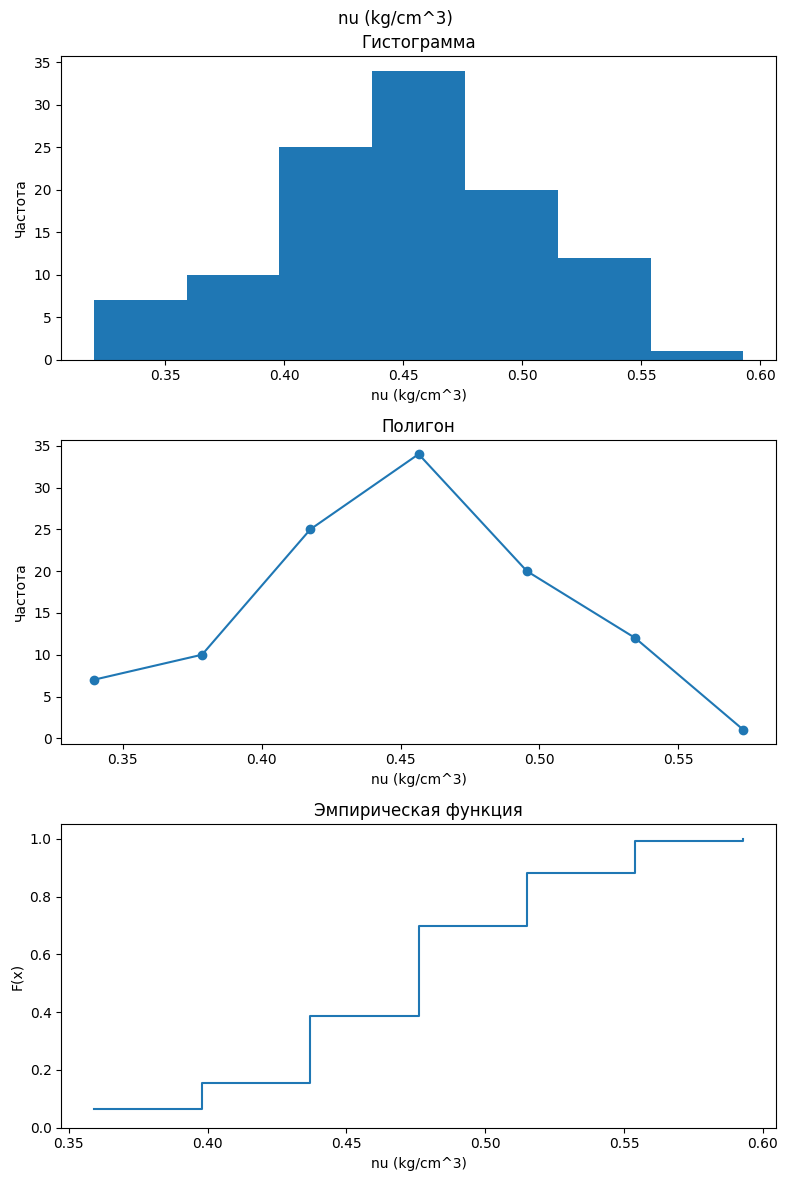

In [89]:
build_plot(interval_nu, NU)

Графики демонстрируют нормальное распределение.

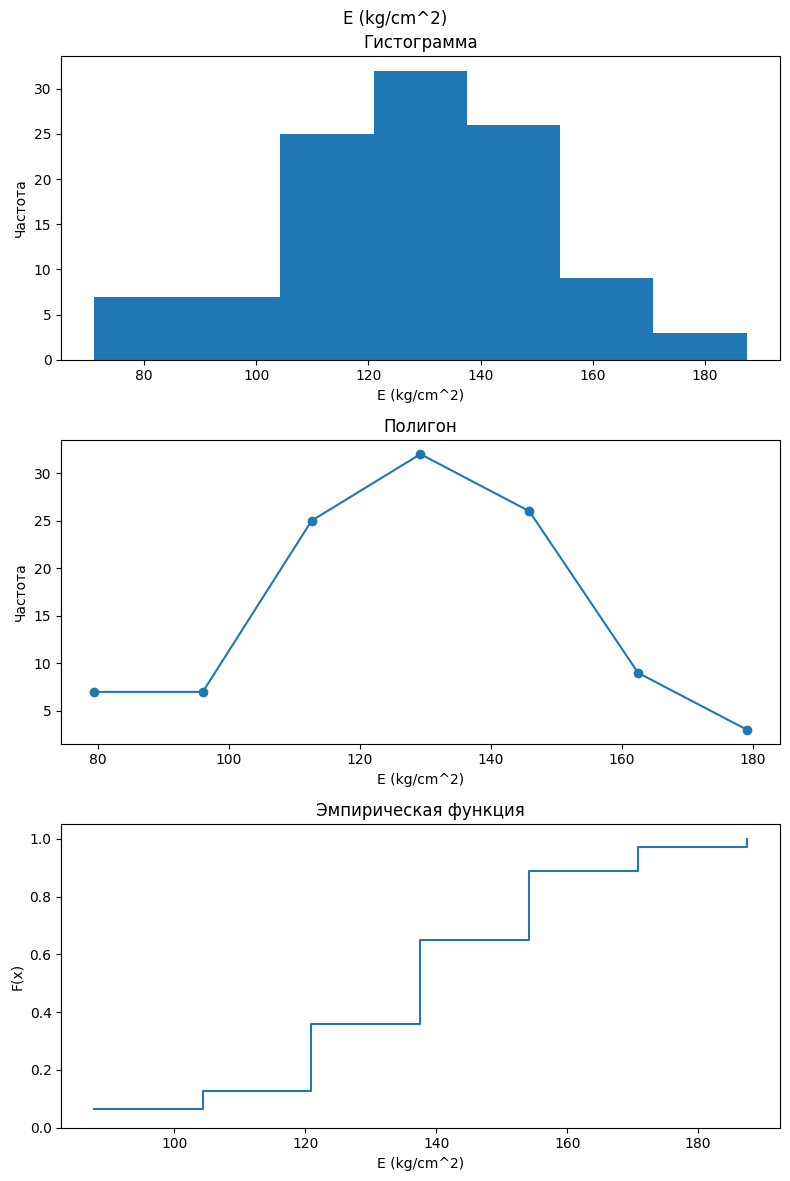

In [90]:
build_plot(interval_e, E)

Графики демонстрируют нормальное распределение.

6. Выполнить п. 5 для относительных частот. Сравнить результаты и сделать выводы.

In [91]:
import matplotlib.pyplot as plt


def build_relative_frequencies_plot(table: pd.DataFrame, x: str):
  table_no_sum = table.iloc[:-1]

  intervals = table_no_sum[INTERVAL]
  rel_freq = table_no_sum[RELATIVE_FREQUENCY].astype(float)
  mid = table_no_sum[MIDRANGE].astype(float)
  cum_rel = table_no_sum[RELATIVE_FREQUENCY_CUM_SUM].astype(float)

  left = np.array([interval.left for interval in intervals])
  right = np.array([interval.right for interval in intervals])
  width = right - left

  fig, axes = plt.subplots(3, 1, figsize=(8, 12))
  fig.suptitle(x)

  axes[0].bar(left, rel_freq, width=width, align='edge')
  axes[0].set_title('Гистограмма (относительные частоты)')
  axes[0].set_xlabel(x)
  axes[0].set_ylabel('Частота')

  axes[1].plot(mid, rel_freq, marker='o')
  axes[1].set_title('Полигон (относительные частоты)')
  axes[1].set_xlabel(x)
  axes[1].set_ylabel('Частота')

  axes[2].step(right, cum_rel, where='post')
  axes[2].set_title('Эмпирическая функция')
  axes[2].set_xlabel(x)
  axes[2].set_ylabel('F(x)')
  axes[2].set_ylim(0, 1.05)

  plt.tight_layout()
  plt.show()


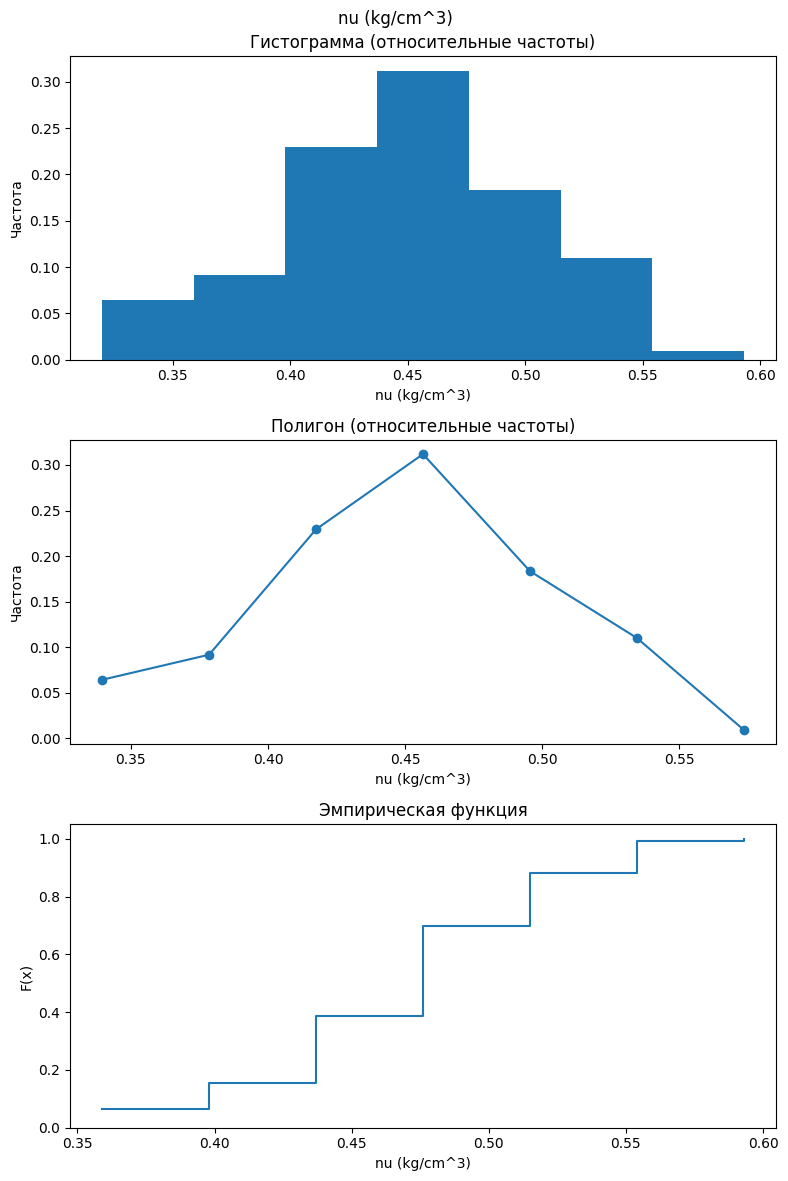

In [92]:
build_relative_frequencies_plot(interval_nu, NU)

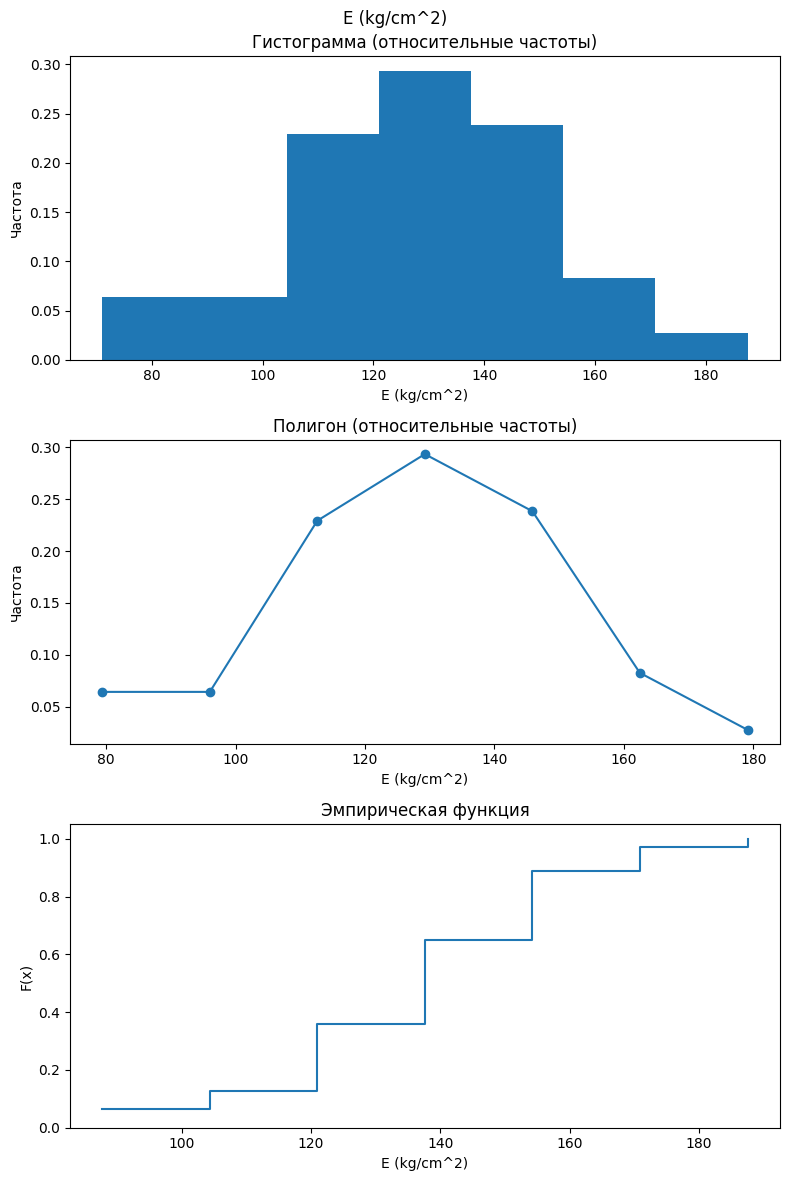

In [93]:
build_relative_frequencies_plot(interval_e, E)

Форма распределения идентична графикам с абсолютными частотами. Отличается только масштаб оси ординат. Относительные частоты удобнее использовать, когда нужно сравнить распределение разных выборок.

## Выводы

Были изучены основные правила формирования выборки. Была проведена подготовка данных к статистическому анализу. Выборочные данные преобразованы в ранжированный, вариационный и интервальный ряды. Полученные ряды были проанализированы. На основе интервального ряда построена гистограмма, полигон частот и эмпирическая функция распределения. Анализ графиков показал нормальное распределение выборки. Проведено сопоставление графиков относительных частот с графиками абсолютных частот. Сопоставление показало, что графики идентичны по форме распределения и отличаются лишь масштабом оси ординат.